In [4]:
# 1. Install ultralytics
!pip install ultralytics

# 2. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from ultralytics import YOLO
from ultralytics.nn.modules.block import C2f
import yaml
import os

# ==========================================
# 1. CUSTOM SFS_CONV ARCHITECTURE
# ==========================================
def autopad(k, p=None, d=1):
    if d > 1:
        k = d * (k - 1) + 1 if isinstance(k, int) else [d * (x - 1) + 1 for x in k]
    if p is None:
        p = k // 2 if isinstance(k, int) else [x // 2 for x in k]
    return p

class Conv(nn.Module):
    default_act = nn.SiLU()

    def __init__(self, c1, c2, k=1, s=1, p=None, g=1, d=1, act=True):
        super().__init__()
        self.conv = nn.Conv2d(c1, c2, k, s, autopad(k, p, d), groups=g, dilation=d, bias=False)
        self.bn   = nn.BatchNorm2d(c2)
        self.act  = self.default_act if act is True else (act if isinstance(act, nn.Module) else nn.Identity())

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class SPU(nn.Module):
    def __init__(self, in_channels, out_channels, n=4):
        super().__init__()
        assert in_channels % n == 0
        self.n        = n
        self.group_ch = in_channels // n
        self.convs    = nn.ModuleList(
            Conv(self.group_ch, self.group_ch, k=3 + 2*g, g=self.group_ch)
            for g in range(n)
        )
        self.fuse = Conv(in_channels, out_channels, 1)

    def forward(self, x):
        groups  = x.chunk(self.n, dim=1)
        outputs, prev = [], None
        for conv_g, x_g in zip(self.convs, groups):
            inp = x_g if prev is None else x_g + prev
            y_g = conv_g(inp)
            outputs.append(y_g)
            prev = y_g
        y = self.fuse(torch.cat(outputs, dim=1))
        return y + x if x.shape == y.shape else y

def _make_gabor_kernel(size, angle, scale, order=0.25):
    h, w = size
    x, y = np.meshgrid(np.linspace(-1, 1, w), np.linspace(-1, 1, h))
    x_t  =  x * np.cos(angle) + y * np.sin(angle)
    y_t  = -x * np.sin(angle) + y * np.cos(angle)
    kernel = (
        np.exp(-((x_t**2 + (y_t / scale)**2) ** order)) *
        np.cos(2 * np.pi * x_t / scale)
    ).astype(np.float32)
    return torch.from_numpy(kernel).view(1, 1, h, w)

class FrGKConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3,
                 orientations=(0, 45, 90, 135), scale=1.0, order=0.25):
        super().__init__()
        k = kernel_size
        self.weight = nn.Parameter(torch.empty(out_ch, in_ch, k, k))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        gabor = sum(
            _make_gabor_kernel((k, k), np.radians(a), scale, order)
            for a in orientations
        )
        gabor = gabor / (gabor.abs().max() + 1e-6)
        self.register_buffer("gabor", gabor.expand(out_ch, 1, k, k))
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.ReLU(inplace=True)
        self.drop = nn.Dropout2d(0.1)

    def forward(self, x):
        w   = self.weight * self.gabor
        out = F.conv2d(x, w, padding=(w.shape[-1] - 1) // 2)
        return self.drop(self.act(self.bn(out)))

class FPU(nn.Module):
    def __init__(self, in_channels, out_channels,
                 scales=(0.5, 1.0, 1.5, 2.0), order=0.25,
                 orientations=(0, 45, 90, 135)):
        super().__init__()
        V = len(scales)
        assert in_channels % V == 0
        self.V        = V
        self.group_ch = in_channels // V
        self.branches = nn.ModuleList(
            FrGKConv(self.group_ch, out_channels // V,
                     kernel_size=3, orientations=orientations,
                     scale=s, order=order)
            for s in scales
        )
        self.fuse = Conv(out_channels, out_channels, 1)

    def forward(self, x):
        groups = x.chunk(self.V, dim=1)
        out    = self.fuse(torch.cat([b(g) for b, g in zip(self.branches, groups)], dim=1))
        return out + x if x.shape == out.shape else out

class CSU(nn.Module):
    def forward(self, ys, yf):
        s_s     = ys.mean(dim=(-2, -1), keepdim=True)
        s_f     = yf.mean(dim=(-2, -1), keepdim=True)
        weights = torch.softmax(torch.stack([s_s, s_f], dim=0), dim=0)
        return weights[0] * ys + weights[1] * yf

class SFS_Conv(nn.Module):
    def __init__(self, in_channels, out_channels,
                 alpha=0.5, order=0.25, n_spu=4):
        super().__init__()
        scales       = (0.5, 1.0, 1.5, 2.0)
        orientations = (0, 45, 90, 135)

        c_f = max(len(scales), int(in_channels * alpha))
        c_f = (c_f // len(scales)) * len(scales)
        c_s = in_channels - c_f
        c_s = max(n_spu, (c_s // n_spu) * n_spu)

        self.PWC_s   = Conv(in_channels, c_s, 1)
        self.PWC_f   = Conv(in_channels, c_f, 1)
        self.SPU     = SPU(c_s, out_channels, n=n_spu)
        self.FPU     = FPU(c_f, out_channels, scales=scales,
                           order=order, orientations=orientations)
        self.CSU     = CSU()
        self.PWC_out = Conv(out_channels, out_channels, 1)
        self.skip    = (nn.Identity() if in_channels == out_channels
                        else Conv(in_channels, out_channels, 1))

    def forward(self, x):
        y_s = self.SPU(self.PWC_s(x))
        y_f = self.FPU(self.PWC_f(x))
        y   = self.PWC_out(self.CSU(y_s, y_f))
        return y + self.skip(x)


# ==========================================
# 2. YOLOv8 PATCHING LOGIC
# ==========================================
def patch_model_with_sfs_conv(yolo_model):
    pytorch_model = yolo_model.model
    deep_c2f_indices = [6, 8, 12, 15, 18, 21]
    patch_count = 0
    for idx in deep_c2f_indices:
        if idx < len(pytorch_model.model) and isinstance(pytorch_model.model[idx], C2f):
            c2f_layer = pytorch_model.model[idx]
            for bottleneck in c2f_layer.m:
                c1 = bottleneck.cv1.conv.in_channels
                c_out = bottleneck.cv1.conv.out_channels
                bottleneck.cv1 = SFS_Conv(c1, c_out)
                patch_count += 1

    print(f"\n[INFO] Successfully injected SFS_Conv into {patch_count} Bottleneck blocks!\n")
    return yolo_model


# ==========================================
# 3. AUTO-GENERATE YAML & START TRAINING
# ==========================================
dataset_dir = "/content/drive/MyDrive/HRSID_YOLO"
yaml_path = f"{dataset_dir}/hrsid_data.yaml"
yaml_content = {
    "train": f"{dataset_dir}/images/train",
    "val": f"{dataset_dir}/images/val",
    "nc": 1,
    "names": ["ship"]
}
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)
print(f"[INFO] Created Dataset YAML file at: {yaml_path}")
SAVE_DIR = "/content/drive/MyDrive/SFS_YOLO_Runs"
model = YOLO("yolov8n.pt")
model = patch_model_with_sfs_conv(model)
print("Starting training with the custom architecture on the T4 GPU...")
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    project=SAVE_DIR
)
print("Training finished!")


[INFO] Created Dataset YAML file at: /content/drive/MyDrive/HRSID_YOLO/hrsid_data.yaml

[INFO] Successfully injected SFS_Conv into 7 Bottleneck blocks!

Starting training with the custom architecture on the T4 GPU...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/HRSID_YOLO/hrsid_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0

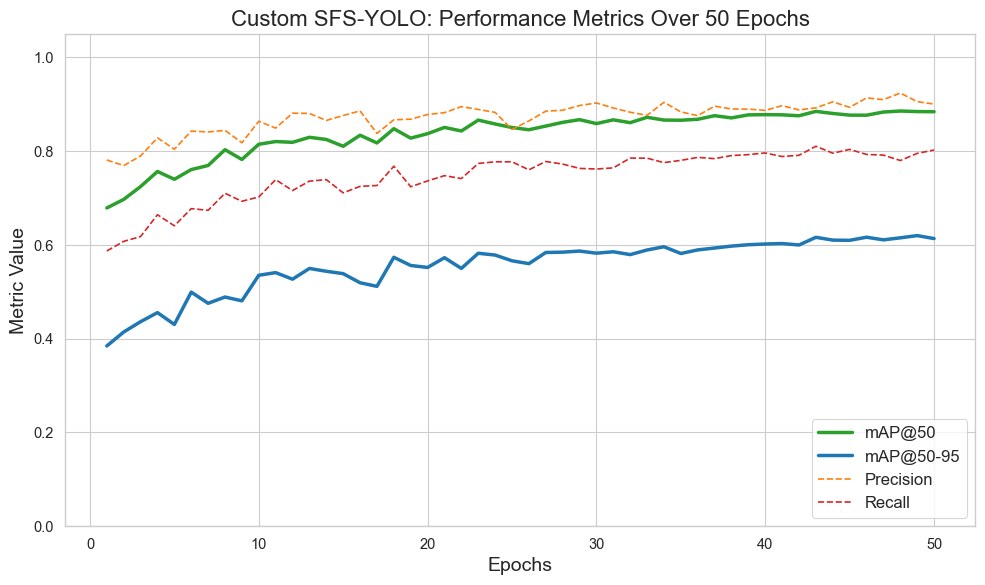

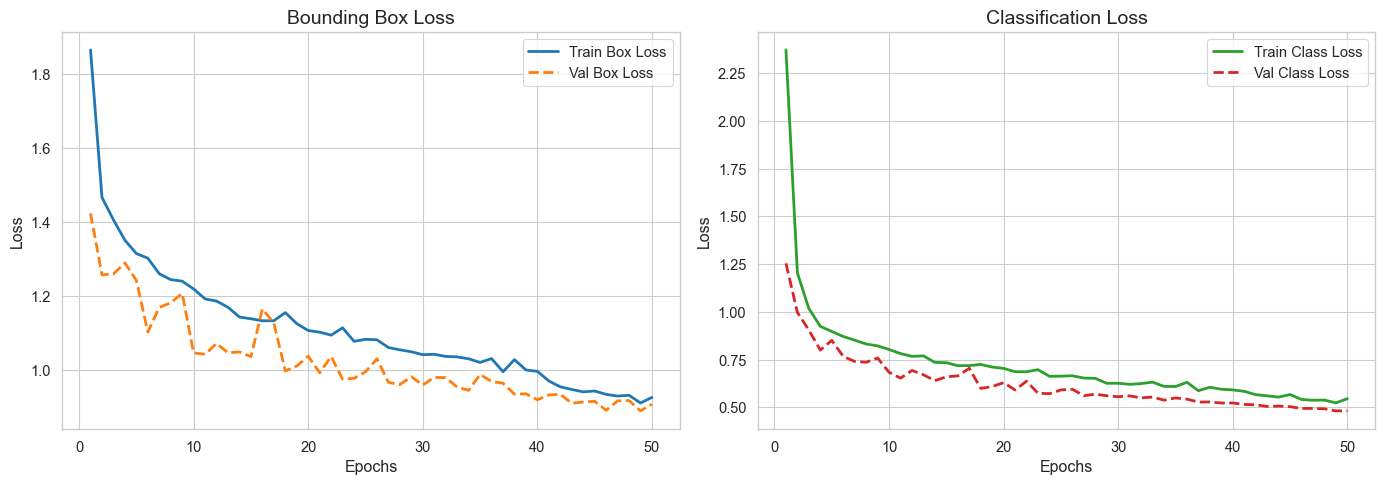

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD THE RESULTS CSV
# ==========================================

CSV_PATH = "/content/drive/MyDrive/SFS_YOLO_Runs/train5/results.csv"

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# ==========================================
# 2. PLOT: METRICS (mAP & Precision/Recall)
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='#2ca02c', linewidth=2.5)
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='#1f77b4', linewidth=2.5)
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='#ff7f0e', linestyle='--')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='#d62728', linestyle='--')

plt.title('Custom SFS-YOLO: Performance Metrics Over 50 Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Metric Value', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 3. PLOT: TRAINING VS VALIDATION LOSS
# ==========================================
plt.figure(figsize=(14, 5))

# --- Box Loss Subplot ---
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='#1f77b4', linewidth=2)
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='#ff7f0e', linewidth=2, linestyle='--')
plt.title('Bounding Box Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- Class/Objectness Loss Subplot ---
plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', color='#2ca02c', linewidth=2)
plt.plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', color='#d62728', linewidth=2, linestyle='--')
plt.title('Classification Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
import torch

from ultralytics import YOLO
import yaml
import os
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

print("PyTorch and YOLO loaded successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch and YOLO loaded successfully!


In [6]:
#TRAINING BASELINE YOLOV8 FROM SCRATCH
import yaml
import os
from ultralytics import YOLO

# 1. Define Drive paths
dataset_dir = "/content/drive/MyDrive/HRSID_YOLO"
yaml_path = f"{dataset_dir}/hrsid_data.yaml"
SAVE_DIR = "/content/drive/MyDrive/HRSID_Baseline_Scratch_Runs"

# 2. Re-create or confirm the YAML content
yaml_content = {
    "train": f"{dataset_dir}/images/train",
    "val": f"{dataset_dir}/images/val",
    "nc": 1,
    "names": ["ship"]
}

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)
print(f"[INFO] Verified Dataset YAML file at: {yaml_path}")

# 3. LOAD FROM SCRATCH:
print("[INFO] Initializing YOLOv8 network from scratch (no pre-trained weights)...")
model = YOLO("yolov8n.yaml")

# 4. Start the training process
print("[INFO] Starting training from scratch on T4 GPU for 50 epochs...")
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    project=SAVE_DIR
)
print("Training finished!")


[INFO] Verified Dataset YAML file at: /content/drive/MyDrive/HRSID_YOLO/hrsid_data.yaml
[INFO] Initializing YOLOv8 network from scratch (no pre-trained weights)...
[INFO] Starting training from scratch on T4 GPU for 50 epochs...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/HRSID_YOLO/hrsid_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_wid